# Debugging

This notebook demonstrates how to configure and control logging in the *OptiWindNet* to debug wind farm network optimization workflows. We explore logging at different scopes (individual modules and multiple modules). Additionally, we cover enabling verbose output for MILP solvers to inspect solver behavior in detail, observing optimization performance and progress.

In [1]:
import sys
import logging
from optiwindnet.api import WindFarmNetwork, HGSRouter, MILPRouter

## Logging

### Print a module's debug messages (optiwindnet.mesh)

As an example, we set the logging level for a specific module to `DEBUG` level.

In [2]:
logger_mesh = logging.getLogger('optiwindnet.mesh')
stdout_handler = logging.StreamHandler(stream=sys.stdout)
logger_mesh.addHandler(stdout_handler)
logger_mesh.setLevel(logging.DEBUG)

Initialize a `WindFarmNetwork()` instance:

In [3]:
wfn1 = WindFarmNetwork.from_yaml(filepath='data/example_location.yaml', cables=4)

Run optimization and see the debug log.

In [4]:
res1 = wfn1.optimize()

PART A
PART B
PART C
is_hole: False, ring: 0, num_vertices: 4
((-0.25564496185965113, 0.07687039890429721), (-0.0964256500979665, -0.015065913370998107), (-0.08974871121763778, -0.0073617531244649795), (-0.15754532138712932, 0.16598185242253038))
is_hole: False, ring: 1, num_vertices: 4
((0.24435503814034887, -0.13781886663242596), (-0.010909471361448774, 0.030131826741996243), (-0.021181685023492942, 0.021143639787707592), (0.03916757024101656, -0.18840951891799348))
is_hole: True, ring: 0, num_vertices: 4
((0.10285529494569041, 0.11898647491867832), (0.15421636325591126, 0.10614620784112311), (0.15421636325591126, 0.05221708611539121), (0.138808042762845, 0.04708097928436913))
PART D
PART E
PART F
convex_hull_A: [5, 11, 9, 7, 0, 1, 3, 4]
hull_prunned: [5, 11, 9, 7, 0, 1, 3, 4]
hull_prunned_edges: {(0, 1), (0, 7), (5, 11), (3, 4), (7, 9), (4, 5), (9, 11), (1, 3)}
PART G
hull_concave: [-1, 6, 11, 9, 7, 6, -1, 2, 0, 1, 3, 4, 5]
PART H
holes
s: 22, t: 23, sC: (0.138808042762845, 0.047080

### Another example (optiwindnet.pathfinding)

Logging other modules can be activated independently of the already active loggers.

In [5]:
# optional: unset the previous logger level and remove its handler
logger_mesh.setLevel(logging.NOTSET)
logger_mesh.handlers[0].close()
logger_mesh.removeHandler(logger_mesh.handlers[0])

Set a logger for `optiwindnet.pathfinding`:

In [6]:
logger_pathfinding = logging.getLogger('optiwindnet.pathfinding')
stdout_handler = logging.StreamHandler(stream=sys.stdout)
logger_pathfinding.addHandler(stdout_handler)
logger_pathfinding.setLevel(logging.DEBUG)

In [7]:
wfn2 = WindFarmNetwork.from_yaml(filepath='data/example_location.yaml', cables=4)

In [8]:
res2 = wfn2.optimize(
    router=HGSRouter(
        time_limit=0.1,
        feeder_limit=3,
    ),
)

>PathFinder: "example_location" (T = 12)
pseudoedge «6->-1» added
pseudoedge «15->-1» added
pseudoedge «15->-1» added
pseudoedge «5->-1» added
_find_paths[1]: advancer id <0>
<0> RIGHT _new(16) _nearside(15) _farside(6) _apex(-1), _wedge_end: 6 15, _funnel: [6, 15]
<0> infranear
_find_paths[2]: advancer id <1>
<1> LEFT  _new(14) _nearside(15) _farside(5) _apex(-1), _wedge_end: 15 5, _funnel: [15, 5]
<1> inside
_find_paths[3]: advancer id <0>
pseudoedge «16->15» added
<0> new keeper for (16, -9223372036854775808) via 15: d_path = 397.67
<0> RIGHT _new(11) _nearside(15) _farside(6) _apex(-1), _wedge_end: 6 16, _funnel: [6, 15]
<0> infranear
_find_paths[4]: advancer id <2>
<2> LEFT  _new(11) _nearside(6) _farside(15) _apex(-1), _wedge_end: 6 16, _funnel: [6, 15]
<2> ultrafar
_find_paths[5]: advancer id <1>
pseudoedge «14->-1» added
<1> new keeper for (14, -9223372036854775808) via -1: d_path = 445.53
<1> RIGHT _new(4) _nearside(5) _farside(14) _apex(-1), _wedge_end: 14 5, _funnel: [14, 5]

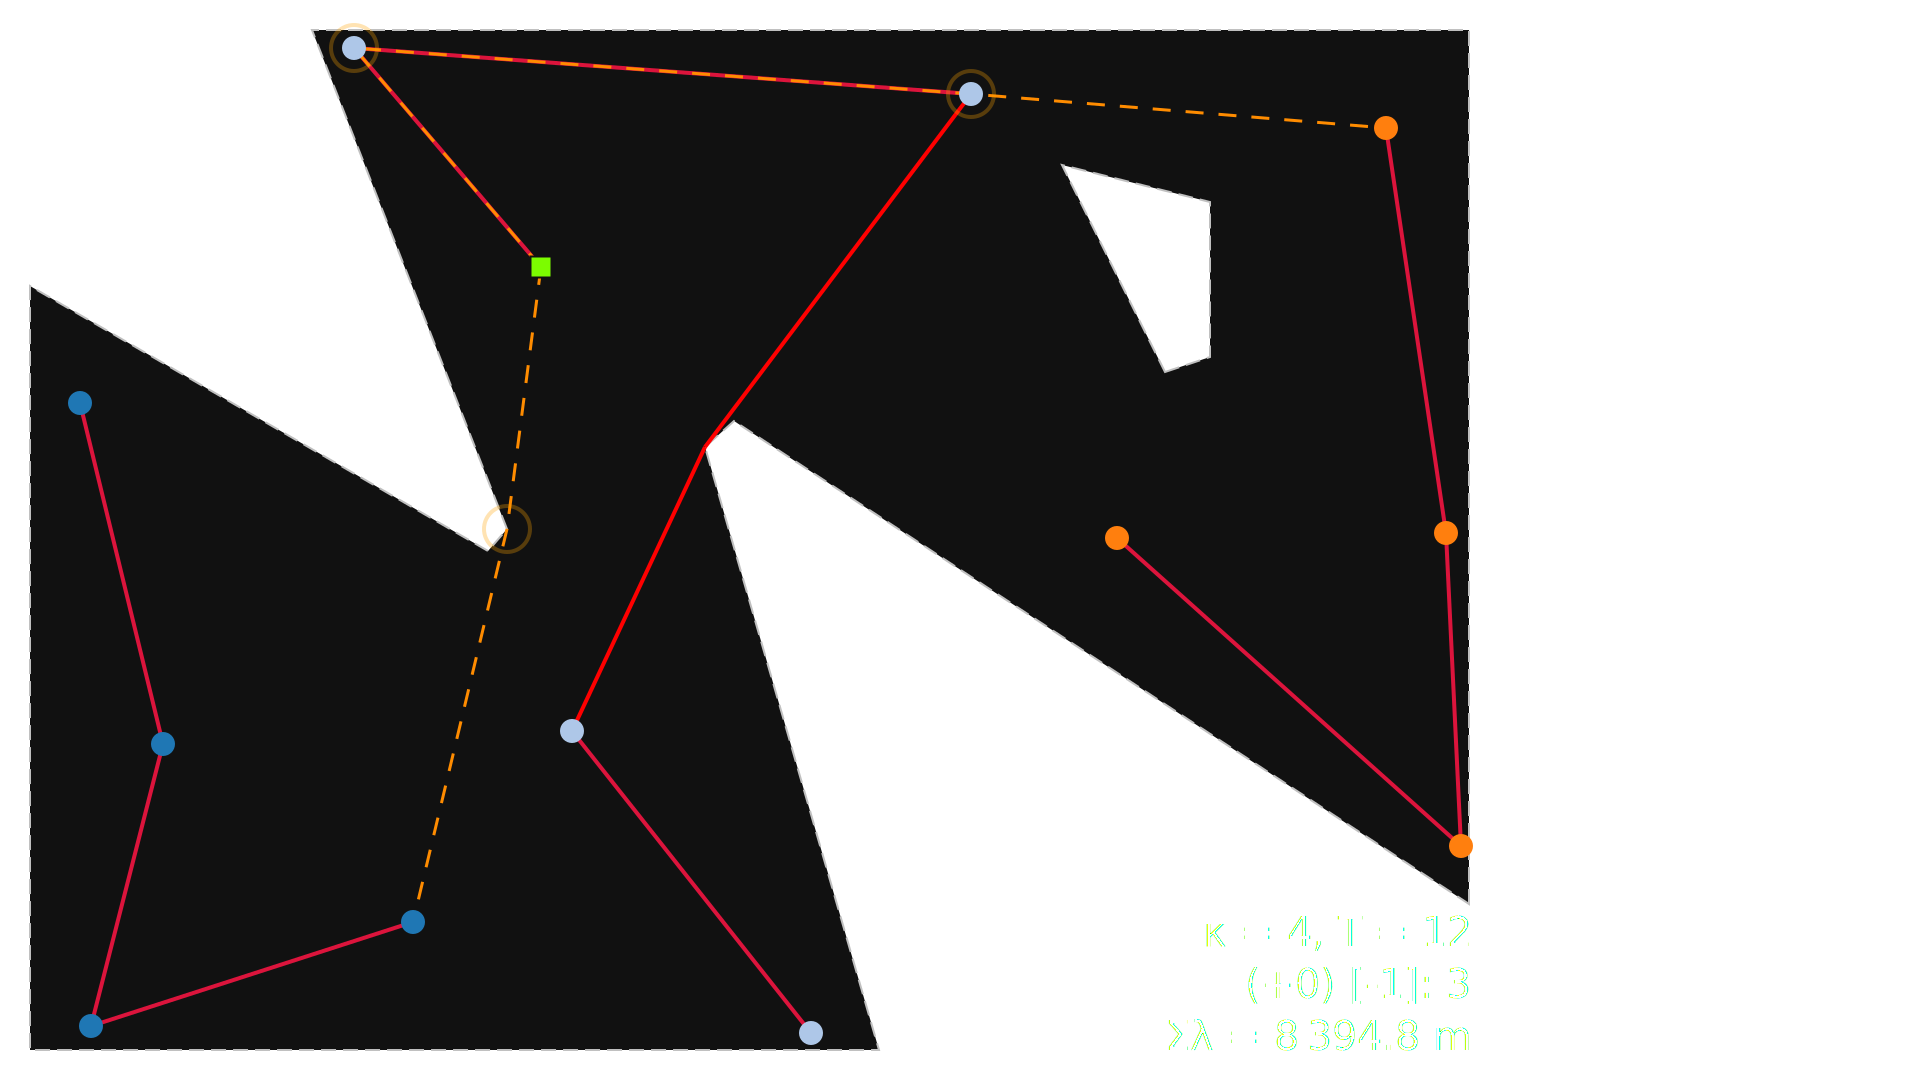

In [9]:
wfn2

### Log all OptiWindNet modules

Logging is hierarchical. By specifying the top-level module, all submodules are included.

In [10]:
# here we use basicConfig to prepend each log message with the source module name
logging.basicConfig(
    level=logging.DEBUG,
    format="%(name)s: %(message)s",
    stream=sys.stdout,
)
logger_own = logging.getLogger('optiwindnet')

In [11]:
wfn3 = WindFarmNetwork.from_yaml(filepath='data/example_location.yaml', cables=4)

In [12]:
res3 = wfn3.optimize()

optiwindnet.mesh: PART A
optiwindnet.mesh: PART B
optiwindnet.mesh: PART C
optiwindnet.mesh: is_hole: False, ring: 0, num_vertices: 4
optiwindnet.mesh: ((-0.25564496185965113, 0.07687039890429721), (-0.0964256500979665, -0.015065913370998107), (-0.08974871121763778, -0.0073617531244649795), (-0.15754532138712932, 0.16598185242253038))
optiwindnet.mesh: is_hole: False, ring: 1, num_vertices: 4
optiwindnet.mesh: ((0.24435503814034887, -0.13781886663242596), (-0.010909471361448774, 0.030131826741996243), (-0.021181685023492942, 0.021143639787707592), (0.03916757024101656, -0.18840951891799348))
optiwindnet.mesh: is_hole: True, ring: 0, num_vertices: 4
optiwindnet.mesh: ((0.10285529494569041, 0.11898647491867832), (0.15421636325591126, 0.10614620784112311), (0.15421636325591126, 0.05221708611539121), (0.138808042762845, 0.04708097928436913))
optiwindnet.mesh: PART D
optiwindnet.mesh: PART E
optiwindnet.mesh: PART F
optiwindnet.mesh: convex_hull_A: [5, 11, 9, 7, 0, 1, 3, 4]
optiwindnet.mesh

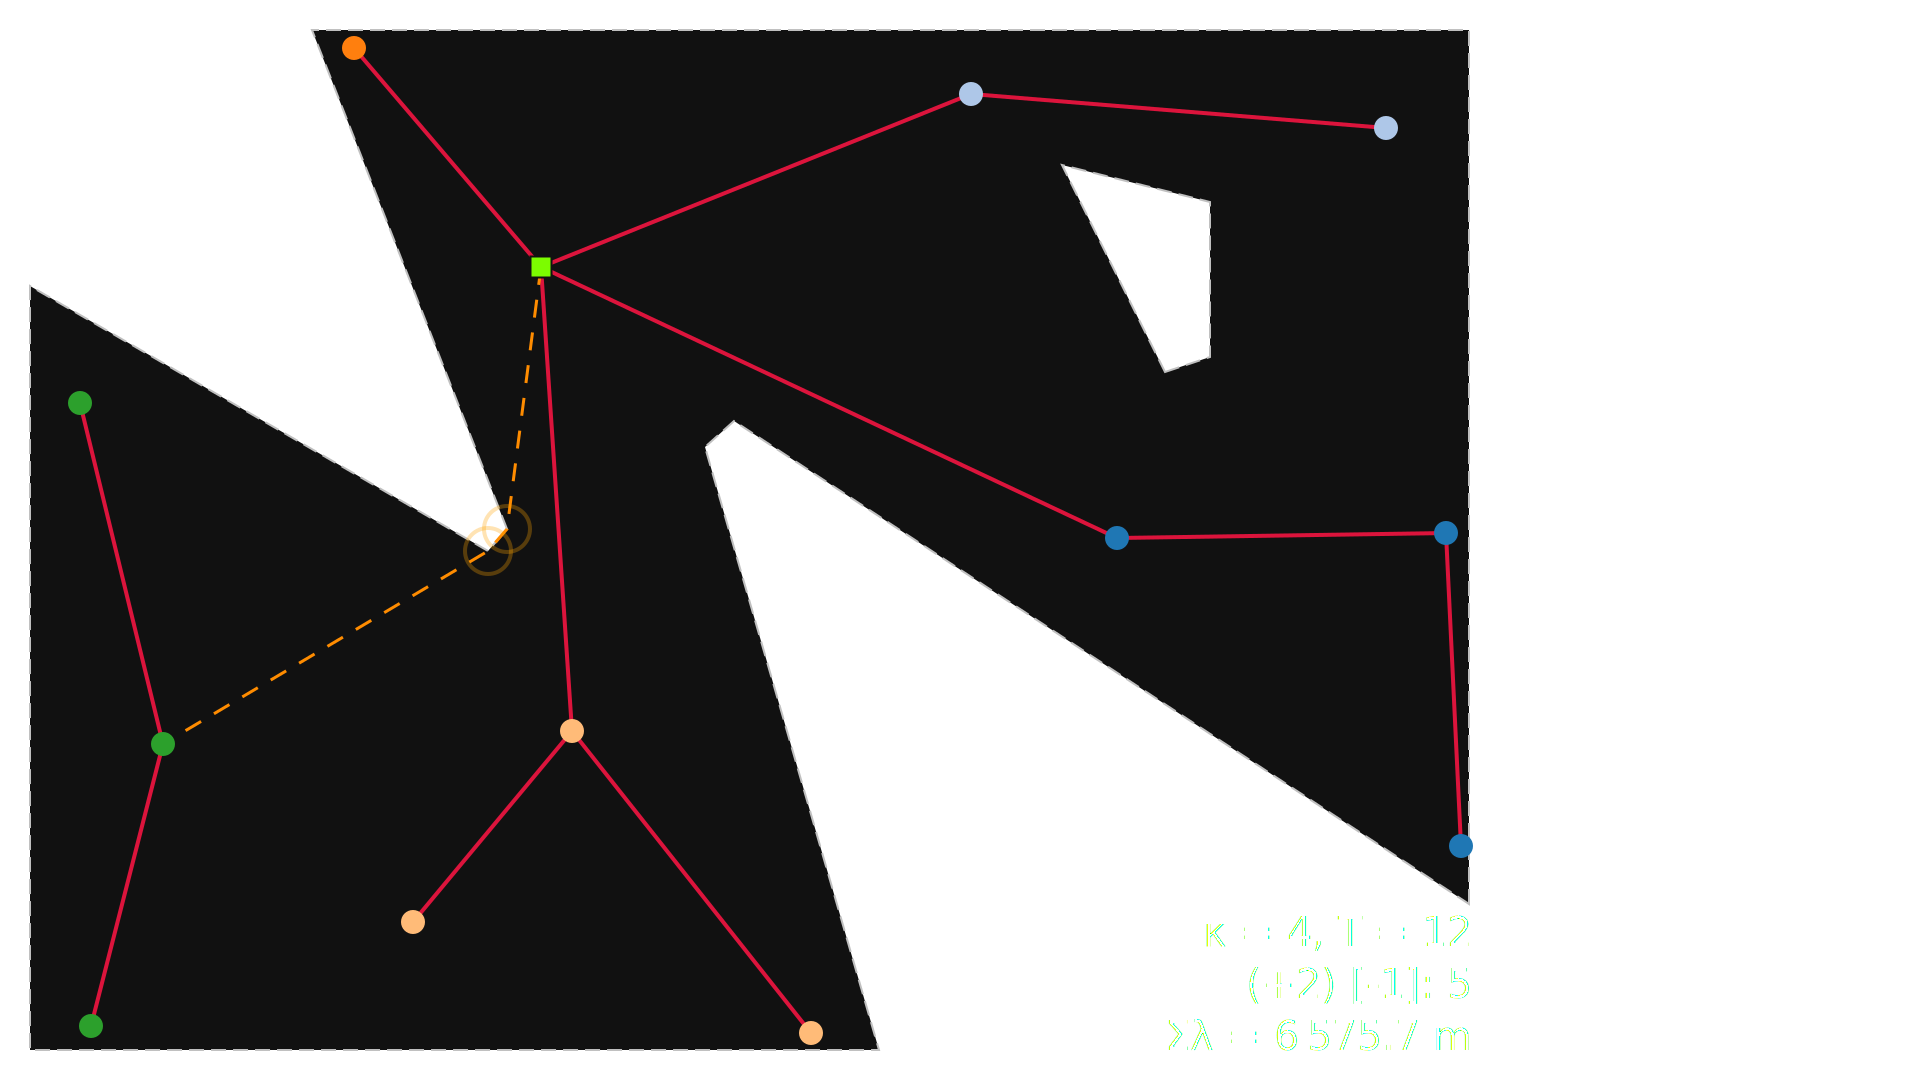

In [13]:
wfn3

Set logging level to `WARNING`, so that we can see only the effect of the `verbose` flag.

In [14]:
logger_own.setLevel(logging.WARNING)
logger_pathfinding.setLevel(logging.WARNING)

## Verbose (non-Python code)

Python's logging only applies to Python code. For OptiWindNet's functionality that is implemented as C extensions or external libraries and programs, a `verbose=True` option may be available.

Verbose is a flag for printing/hiding the MILP solver log (Default is `verbose=False`).

In [15]:
res3 = wfn3.optimize(
    router=MILPRouter(
        solver_name='ortools',
        time_limit=2,
        mip_gap=0.001,
        verbose=True,
    ),
)

Using warm start: the model is initialized with the provided solution S.



Starting CP-SAT solver v9.15.6755
Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 2 log_search_progress: true relative_gap_limit: 0.001
Parameters: max_time_in_seconds: 2 log_search_progress: true relative_gap_limit: 0.001
Setting number of workers to 8
Setting number of workers to 8


Initial optimization model '': (model_fingerprint: 0x9b89b60649d6e071)
#Variables: 156 (#bools: 78 in floating point objective) (132 primary variables)
  - 78 Booleans in [0,1]
  - 66 in [0,3]
  - 12 in [0,4]
#kAtMostOne: 44 (#literals: 112)
#kLinear1: 156 (#enforced: 156)
#kLinearN: 39 (#terms: 390)

Initial optimization model '': (model_fingerprint: 0x9b89b60649d6e071)
#Variables: 156 (#bools: 78 in floating point objective) (132 primary variables)
  - 78 Booleans in [0,1]
  - 66 in [0,3]
  - 12 in [0,4]
#kAtMostOne: 44 (#literals: 112)
#kLinear1: 156 (#enforced: 156)
#kLinearN: 39 (#terms: 390)
Starting pres

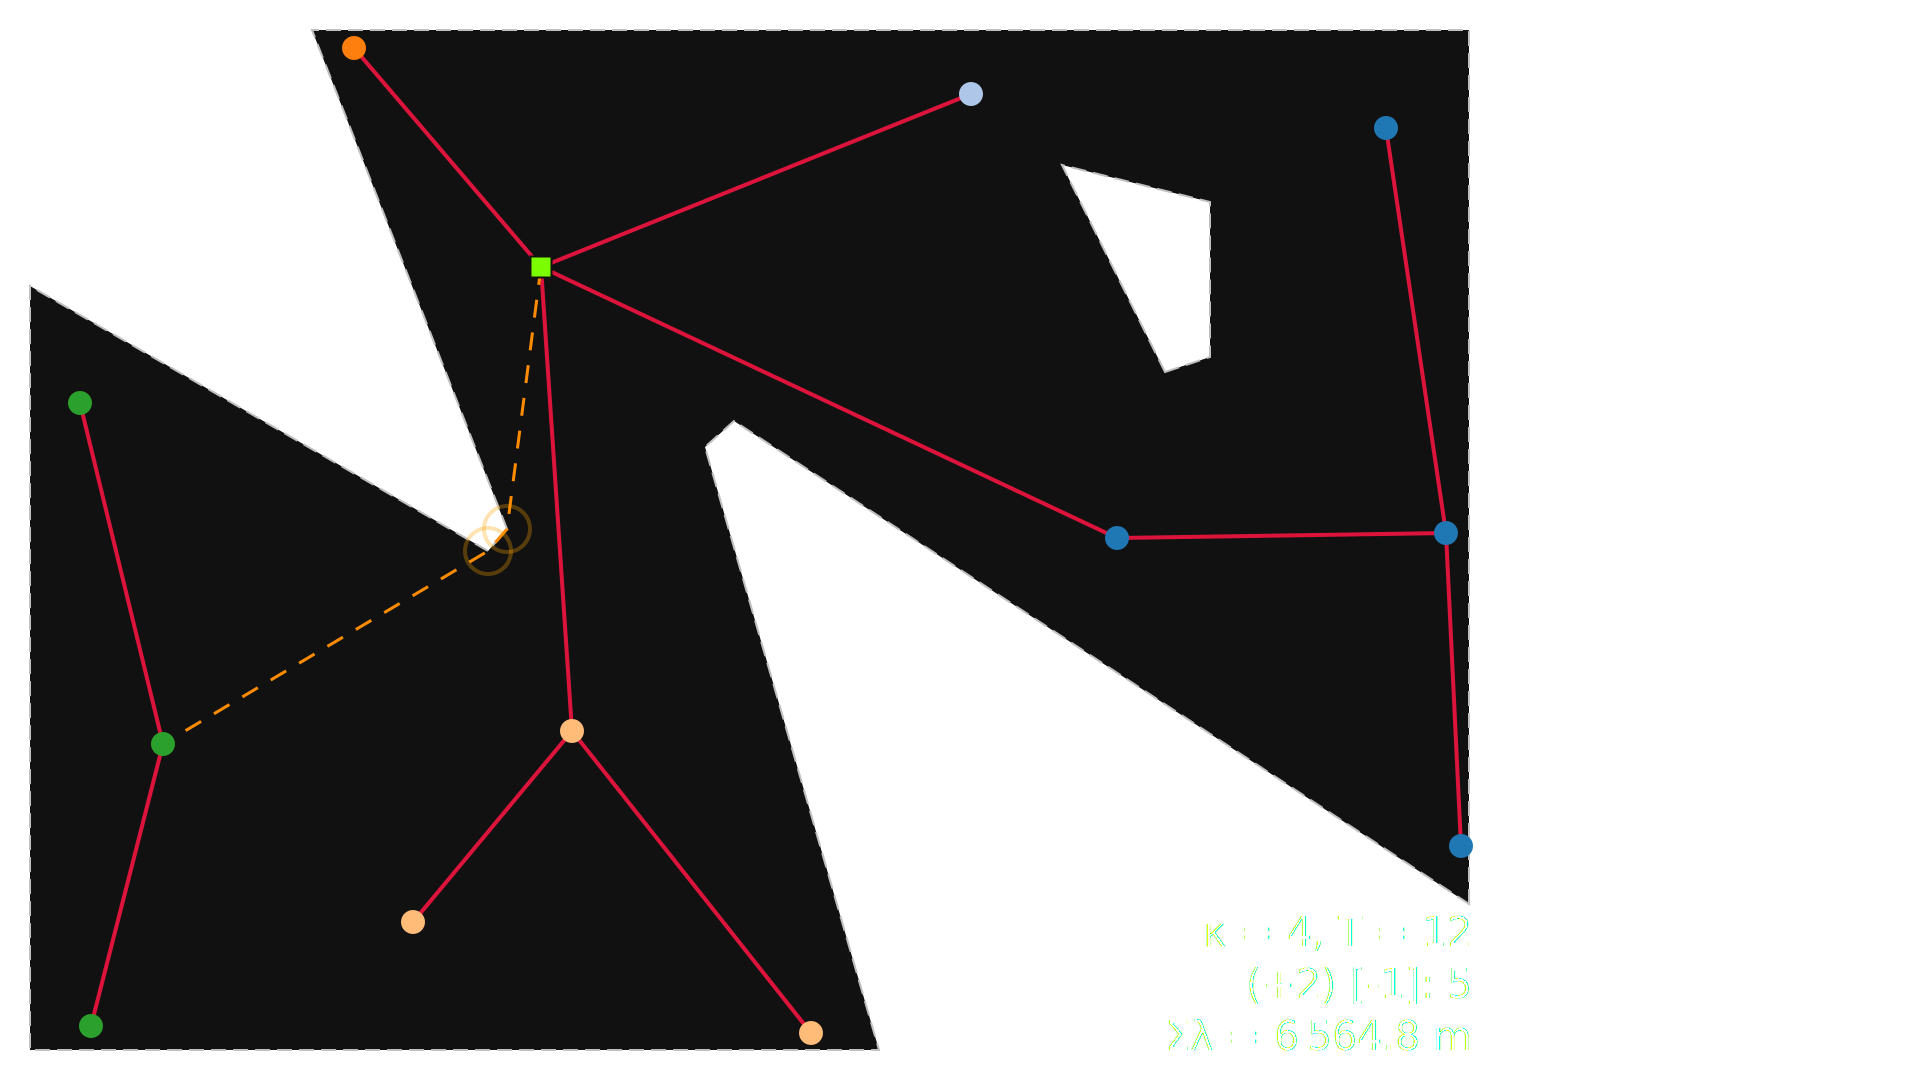

In [16]:
wfn3